In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline 
# To  display the plot in jupyter notebook itself

sns.set_theme(style="whitegrid")

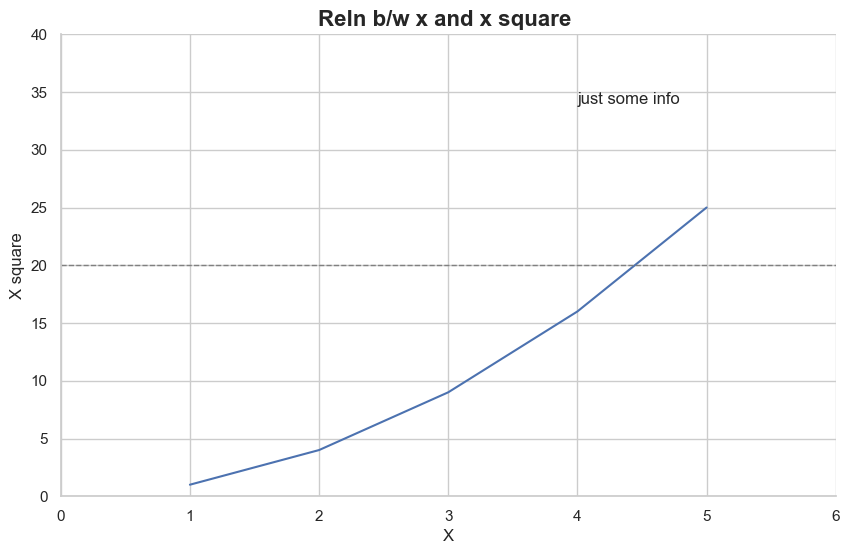

In [19]:

fig , ax = plt.subplots(figsize=(10,6))
# fig is whole picture and ax is axes like whole x and y axis 
# The Figure is the entire plot of land you own. It's the overall window or canvas
# Axis is the actual plot—the area with the x-axis, y-axis, and where the data is drawn.

x = [1,2,3,4,5]
y = [1,4,9,16,25]

ax.plot(x,y)

ax.set_title("Reln b/w x and x square ", fontsize=16,fontweight= 'bold')
ax.set_xlabel("X",fontsize =12)
ax.set_ylabel("X square",fontsize=12)

# Set the limits for the axes
ax.set_xlim(0, 6)
ax.set_ylim(0, 40)


# Spines are the lines that form the box around the plot.
# Let's remove the top and right ones for a cleaner, more modern look.
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axhline(y=20,color='grey',linestyle='--',linewidth=1)
ax.text(x=4, y=34, s="just some info", fontsize=12)

plt.show()

fig.savefig('my_first_graph',dpi=300,bbox_inches= 'tight')
# for saving the photo

In [23]:
sns.set_style("white")

months = pd.to_datetime(['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
                         '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
                         '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01'])
sales = [120, 135, 160, 155, 180, 210, 230, 225, 250, 280, 290, 310]

data = pd.Series(sales,index=months,name='Monthly Sales')
print(data)

2023-01-01    120
2023-02-01    135
2023-03-01    160
2023-04-01    155
2023-05-01    180
2023-06-01    210
2023-07-01    230
2023-08-01    225
2023-09-01    250
2023-10-01    280
2023-11-01    290
2023-12-01    310
Name: Monthly Sales, dtype: int64


310


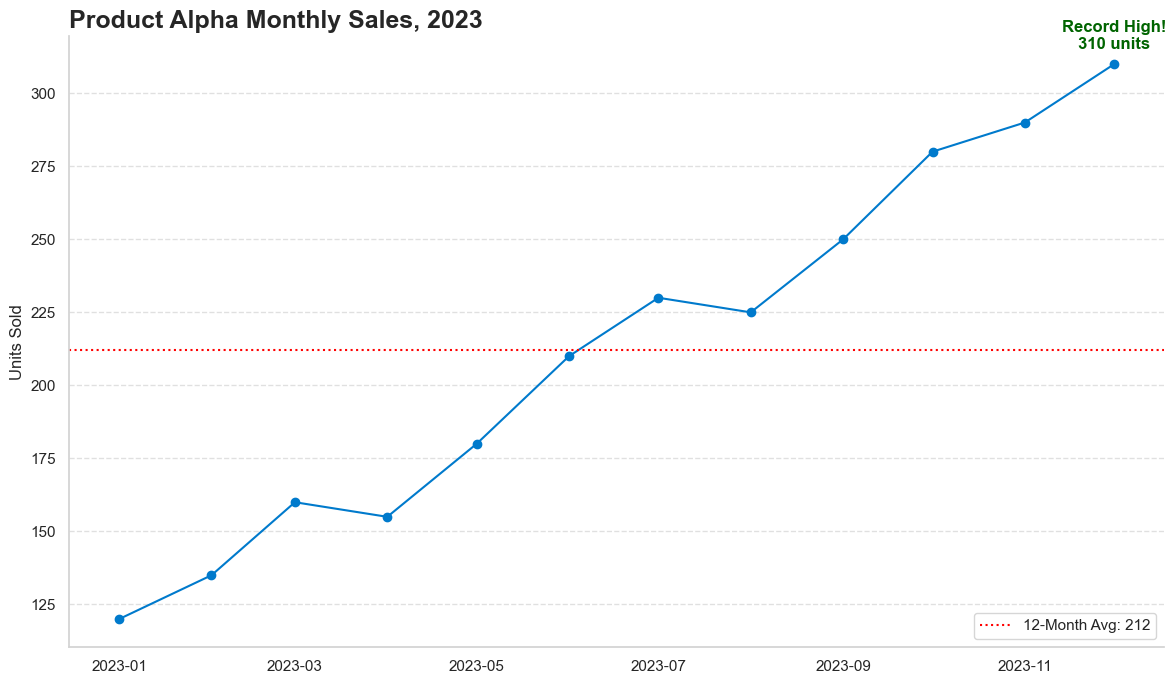

In [42]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(data.index , data.values,marker = 'o',color="#007ACC")

ax.set_title('Product Alpha Monthly Sales, 2023', fontsize=18, fontweight='bold', loc='left')
# loc left will make the loc to the left  side of the title
ax.set_ylabel('Units Sold', fontsize=12)
ax.set_xlabel(None)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('lightgray')
ax.spines['bottom'].set_color('lightgray')
# spines is the border which came with the default graph

ax.grid(axis='y', linestyle='--', alpha=0.6)
# alpha 0.6 means 60 percent opaque and 40 percent transparent

average_sales = data.mean()
ax.axhline(average_sales, color='red', linestyle=':', linewidth=1.5, label=f'12-Month Avg: {average_sales:.0f}')

peak_month = data.idxmax() # max index
peak_value = data.max()  # max value
print(peak_value)

ax.text(peak_month, peak_value + 5, f"Record High!\n{peak_value} units",
        ha='center', color='darkgreen', fontweight='bold')
# `ax.text` is a powerful tool. `ha='center'` centers the text
# horizontally on the coordinate we provided

ax.legend(loc='lower right') # by writing this it will show the label on the top of graph

fig.tight_layout()
plt.show()

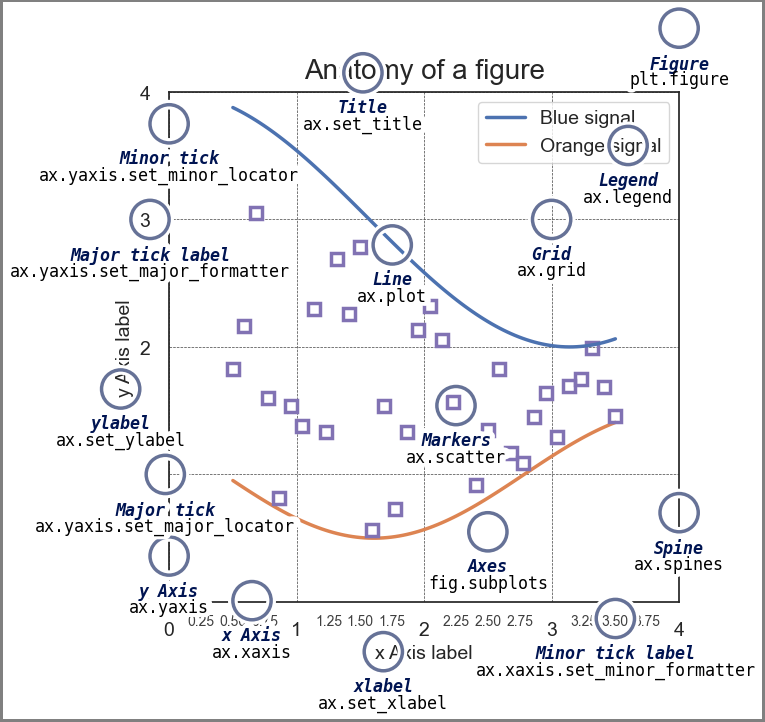

In [43]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Circle
from matplotlib.patheffects import withStroke
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

royal_blue = [0, 20/256, 82/256]


# make the figure

np.random.seed(19680801)

X = np.linspace(0.5, 3.5, 100)
Y1 = 3+np.cos(X)
Y2 = 1+np.cos(1+X/0.75)/2
Y3 = np.random.uniform(Y1, Y2, len(X))

fig = plt.figure(figsize=(7.5, 7.5))
ax = fig.add_axes([0.2, 0.17, 0.68, 0.7], aspect=1)

ax.xaxis.set_major_locator(MultipleLocator(1.000))
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_major_locator(MultipleLocator(1.000))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.xaxis.set_minor_formatter("{x:.2f}")

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)

ax.tick_params(which='major', width=1.0, length=10, labelsize=14)
ax.tick_params(which='minor', width=1.0, length=5, labelsize=10,
               labelcolor='0.25')

ax.grid(linestyle="--", linewidth=0.5, color='.25', zorder=-10)

ax.plot(X, Y1, c='C0', lw=2.5, label="Blue signal", zorder=10)
ax.plot(X, Y2, c='C1', lw=2.5, label="Orange signal")
ax.plot(X[::3], Y3[::3], linewidth=0, markersize=9,
        marker='s', markerfacecolor='none', markeredgecolor='C4',
        markeredgewidth=2.5)

ax.set_title("Anatomy of a figure", fontsize=20, verticalalignment='bottom')
ax.set_xlabel("x Axis label", fontsize=14)
ax.set_ylabel("y Axis label", fontsize=14)
ax.legend(loc="upper right", fontsize=14)


# Annotate the figure

def annotate(x, y, text, code):
    # Circle marker
    c = Circle((x, y), radius=0.15, clip_on=False, zorder=10, linewidth=2.5,
               edgecolor=royal_blue + [0.6], facecolor='none',
               path_effects=[withStroke(linewidth=7, foreground='white')])
    ax.add_artist(c)

    # use path_effects as a background for the texts
    # draw the path_effects and the colored text separately so that the
    # path_effects cannot clip other texts
    for path_effects in [[withStroke(linewidth=7, foreground='white')], []]:
        color = 'white' if path_effects else royal_blue
        ax.text(x, y-0.2, text, zorder=100,
                ha='center', va='top', weight='bold', color=color,
                style='italic', fontfamily='monospace',
                path_effects=path_effects)

        color = 'white' if path_effects else 'black'
        ax.text(x, y-0.33, code, zorder=100,
                ha='center', va='top', weight='normal', color=color,
                fontfamily='monospace', fontsize='medium',
                path_effects=path_effects)


annotate(3.5, -0.13, "Minor tick label", "ax.xaxis.set_minor_formatter")
annotate(-0.03, 1.0, "Major tick", "ax.yaxis.set_major_locator")
annotate(0.00, 3.75, "Minor tick", "ax.yaxis.set_minor_locator")
annotate(-0.15, 3.00, "Major tick label", "ax.yaxis.set_major_formatter")
annotate(1.68, -0.39, "xlabel", "ax.set_xlabel")
annotate(-0.38, 1.67, "ylabel", "ax.set_ylabel")
annotate(1.52, 4.15, "Title", "ax.set_title")
annotate(1.75, 2.80, "Line", "ax.plot")
annotate(2.25, 1.54, "Markers", "ax.scatter")
annotate(3.00, 3.00, "Grid", "ax.grid")
annotate(3.60, 3.58, "Legend", "ax.legend")
annotate(2.5, 0.55, "Axes", "fig.subplots")
annotate(4, 4.5, "Figure", "plt.figure")
annotate(0.65, 0.01, "x Axis", "ax.xaxis")
annotate(0, 0.36, "y Axis", "ax.yaxis")
annotate(4.0, 0.7, "Spine", "ax.spines")

# frame around figure
fig.patch.set(linewidth=4, edgecolor='0.5')
plt.show()

[[1 7 6 0 2 2 0 8 4 9 7 5 9 3 4 2 5 8 1 7 6 5 6 6 7 4 1 8 2 9 7 9 2 2 4 3
  8 3 5 7 5 4 4 8 7 7 4 1 5 8]
 [7 9 5 9 7 1 9 2 8 5 1 8 6 1 7 1 6 7 5 0 5 6 4 1 2 2 7 0 5 5 3 4 3 9 0 3
  4 6 9 1 0 9 8 7 6 3 2 3 7 2]
 [7 2 6 8 5 7 0 7 7 1 9 8 6 6 3 6 9 8 2 6 0 8 3 5 8 2 0 5 2 0 7 8 1 6 5 1
  6 2 8 1 2 2 2 1 4 8 3 3 9 0]]


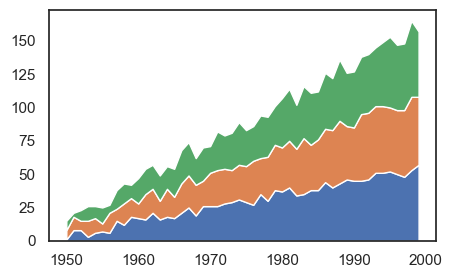

In [50]:
rng = np.arange(50)
rnd = np.random.randint(0, 10, size=(3, rng.size))
print(rnd)

yrs = 1950 + rng

fig, ax = plt.subplots(figsize=(5, 3))
ax.stackplot(yrs, rng + rnd, labels=['Eastasia', 'Eurasia', 'Oceania'])

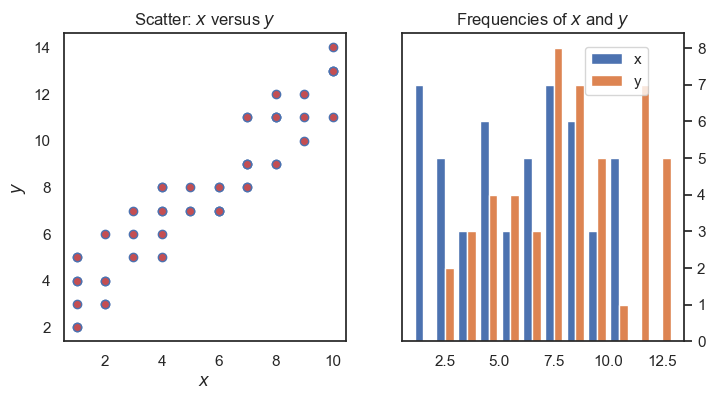

In [60]:
x = np.random.randint(low=1, high=11, size=50)
y = x + np.random.randint(1, 5, size=x.size)
data = np.column_stack((x, y))
# print(x)
# print(y)
# print(data)

fig ,(ax1,ax2) = plt.subplots(nrows = 1, ncols = 2,figsize=(8,4))

ax1.scatter(x=x, y=y, marker='o', c='r', edgecolor='b')
ax1.set_title('Scatter: $x$ versus $y$')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')


ax2.hist(data, bins=np.arange(data.min(), data.max()),
       label=('x', 'y'))
ax2.legend(loc=(0.65, 0.8))
ax2.set_title('Frequencies of $x$ and $y$')
ax2.yaxis.tick_right()

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


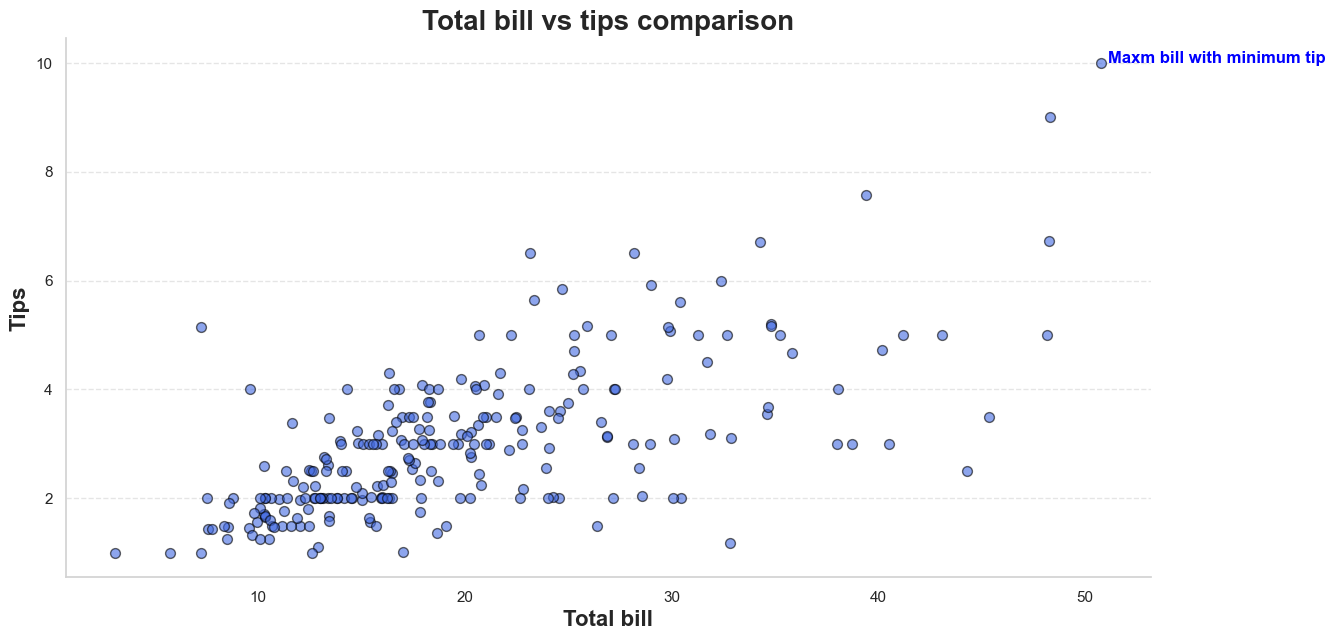

In [92]:
tips = sns.load_dataset('tips')
print(tips)

fig , ax = plt.subplots(figsize= (14,7))

ax.scatter(x= tips['total_bill'] , 
           y = tips['tip'],
           marker='o',
           color='royalblue',
           edgecolors='black',
           alpha=0.6,
            s =50 )   # s is for size  

ax.set_title('Total bill vs tips comparison',fontsize = 20, fontweight= 'bold')
ax.set_ylabel('Tips',fontweight='bold',fontsize= 16)
ax.set_xlabel('Total bill',fontweight='bold',fontsize = 16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('lightgrey')
ax.spines['left'].set_color('lightgrey')

ax.grid(axis='y', linestyle='--', alpha=0.5)

# we are finding which give the max bill

outlier = tips.loc[tips['tip'].idxmax()]
outlier_x = outlier['total_bill']
outlier_y = outlier['tip']

ax.text(outlier_x+0.3, outlier_y,f'Maxm bill with minimum tip',color='blue',fontweight = 'bold')

plt.show()

fig.savefig('tips.png' , dpi=300)